# Analyse des causes de démission chez TechNova Partners

## Etape 1 - Effectuez une analyse exploratoire des fichiers de données

### Objectif

Un DataFrame central, issu d’une jointure entre les fichiers de départ.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# on import les dataset depuis le dossier dataset
df1 = pd.read_csv('dataset/extrait_sirh.csv')
df2 = pd.read_csv('dataset/extrait_eval.csv')
df3 = pd.read_csv('dataset/extrait_sondage.csv')

In [3]:
# entete de chaque dataset
df1.head()
df1.shape

(1470, 12)

In [4]:
# on vas mettre l'index en colonne
#df2 = df2.reset_index()
# eval_number etant un object on le converti en int avec la méthode str.extract comme un regex
# \d chiffre de 0-9 => + un ou plusieurs => () ce qu'on veut extraire
df2["id_employee"] = df2["eval_number"].str.extract(r'(\d+)').astype(int)
# je supprime l'ancien eval
df2 = df2.drop(columns='eval_number')
df2.head()
df2.shape

(1470, 10)

In [5]:
df3.head()
df3.shape

(1470, 12)

In [6]:
# on calcul le taux de correspondances si un taux de 1.0% les deux clé commun sont identique df1 et df2
len(set(df1["id_employee"]) & set(df2["id_employee"])) / len(set(df1["id_employee"]))

1.0

In [7]:
# on identifie les clés communes { ici : id_employee = eval_number = code_sondage  }
# on applique avec pandas un merge 
df_central = pd.merge(df1, df2, on="id_employee", how="left")
df_central.shape

(1470, 21)

In [8]:
#idem pour df_central & df3 on calcul le taux de correspondance
len(set(df_central["id_employee"]) & set(df3["code_sondage"])) / len(set(df_central["id_employee"]))

1.0

In [9]:
# on merge de nouveau df3 dans central
df_central = pd.merge(df_central, df3, left_on="id_employee", right_on="code_sondage" ,how="left")

In [10]:
df_central.shape

(1470, 33)

In [11]:
df_central.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [12]:
df_central.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

In [13]:
# methode pour voir les clés commun avec describe()
# ici je prends id_employer clé principal je regarde les statistiques descriptives
# dans chaque df2 & 3 je vais la descriptives identiques 
df1['id_employee'].describe()

count    1470.000000
mean     1024.865306
std       602.024335
min         1.000000
25%       491.250000
50%      1020.500000
75%      1555.750000
max      2068.000000
Name: id_employee, dtype: float64

In [14]:
# ici n'ayant pas de stats qui corresponds j'analyse manuellement les datas. je remarque que eval_number pourrais correspondre
# mais etant un object je le convertir en int64() => voir méthode au dessus avec .str.extract() avec nouveau nom eval_number_int
# et bingo les stats descriptives sont identiques
df2.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,id_employee
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741,1024.865306
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824,602.024335
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000,491.250000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,1020.500000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,1555.750000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,2068.000000


In [15]:
# ici on peut voir que la colonnes code_sondage est identique a id_employé = donc clé commun
df3.describe()

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129
std,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136
min,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000
50%,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000
75%,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000
max,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000


<Axes: xlabel='satisfaction_employee_environnement', ylabel='Density'>

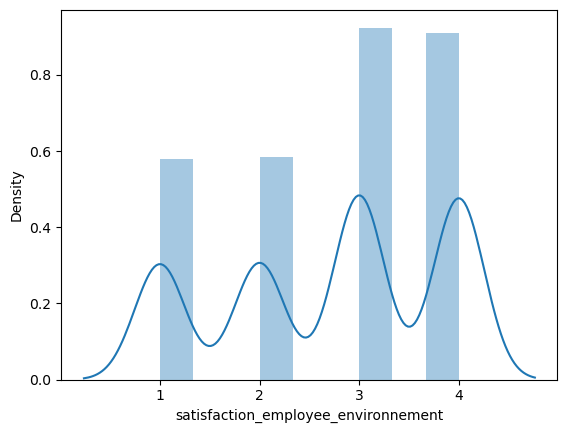

In [16]:
# les trois clés détecté et lié dans un dataframe central on creer les graphiques
sns.distplot(df_central['satisfaction_employee_environnement'])

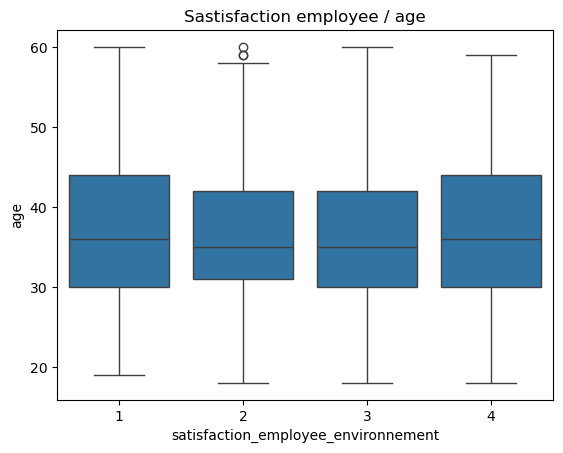

In [17]:
# on vas voir sastifaction employee dans leur environemment
sns.boxplot(data=df_central, y='age', x='satisfaction_employee_environnement')
plt.title('Sastisfaction employee / age')
plt.show()

<Axes: xlabel='a_quitte_l_entreprise', ylabel='satisfaction_employee_environnement'>

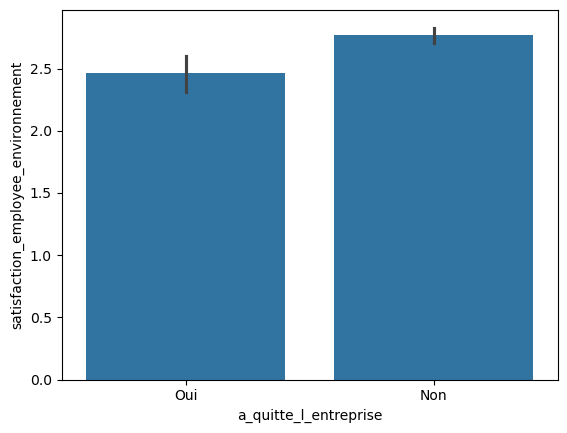

In [18]:
# satisfaction employee environnement
sns.barplot(data=df_central, x="a_quitte_l_entreprise", y="satisfaction_employee_environnement")

<Axes: xlabel='age'>

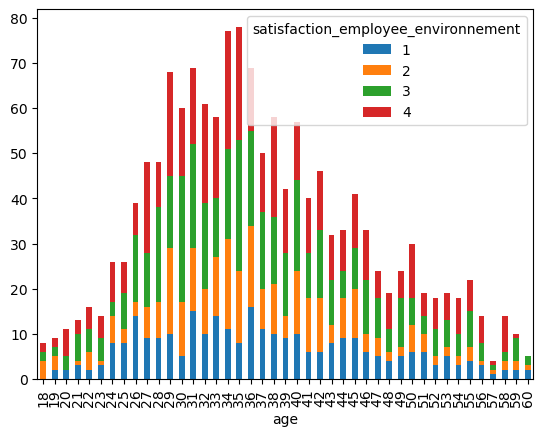

In [19]:
pd.crosstab(df_central['age'], df_central['satisfaction_employee_environnement']).plot(kind='bar', stacked=True)

## Etape 2 - Préparez la donnée pour la modélisation

### Objectif

Préparez la donnée pour la modélisation

In [20]:
# on verifie le dataset avant de faire un corrélation et scaler 
df_central.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   id_employee                                1470 non-null   int64 
 1   age                                        1470 non-null   int64 
 2   genre                                      1470 non-null   object
 3   revenu_mensuel                             1470 non-null   int64 
 4   statut_marital                             1470 non-null   object
 5   departement                                1470 non-null   object
 6   poste                                      1470 non-null   object
 7   nombre_experiences_precedentes             1470 non-null   int64 
 8   nombre_heures_travailless                  1470 non-null   int64 
 9   annee_experience_totale                    1470 non-null   int64 
 10  annees_dans_l_entreprise            

In [21]:
# on transform les object en numérique avec getdummies () idem à OneHotEncoder 
#df = pd.get_dummies(df_central, columns=['genre', ], drop_first=True)
print()
for col, value in df_central.dtypes.items():
    if value == 'object':
        #print(col ,'-', value)
        df_central = pd.get_dummies(df_central, columns=[col], drop_first=True)
        
# on controle de nouveau 
df_central.info() # avec info() on apercois que dtype est converti en bool or pour afficher le grap avec sns.heatmap on aura une erreur



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 59 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   revenu_mensuel                             1470 non-null   int64
 3   nombre_experiences_precedentes             1470 non-null   int64
 4   nombre_heures_travailless                  1470 non-null   int64
 5   annee_experience_totale                    1470 non-null   int64
 6   annees_dans_l_entreprise                   1470 non-null   int64
 7   annees_dans_le_poste_actuel                1470 non-null   int64
 8   satisfaction_employee_environnement        1470 non-null   int64
 9   note_evaluation_precedente                 1470 non-null   int64
 10  niveau_hierarchique_poste                  1470

In [22]:
# on converti les bool en int
# on utilise un boucle 
df_central = df_central.astype({col:int for col, value in df_central.dtypes.items() if value == 'bool'  })

In [23]:
# on fais un nettoyage des données NaN
df_central = df_central.dropna()

In [24]:
# on corr()
df_corr = df_central.copy()
df_corr.corr()


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,...,augementation_salaire_precedente_24 %,augementation_salaire_precedente_25 %,a_quitte_l_entreprise_Oui,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel
id_employee,1.000000,-0.010145,-0.014829,-0.001251,NaN,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,...,-0.002897,0.033069,-0.010577,0.005938,-0.000609,-0.014487,0.035345,-0.008689,-0.007980,-0.007976
age,-0.010145,1.000000,0.497855,0.299635,NaN,0.680381,0.311309,0.212901,0.010146,0.029820,...,0.008537,-0.003812,-0.159205,-0.027604,0.016824,0.038162,0.001696,-0.006354,-0.024743,0.028791
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,NaN,0.772893,0.514285,0.363818,-0.006259,-0.015271,...,0.008805,0.018788,-0.159840,-0.049695,-0.007054,0.062576,0.021456,0.001025,-0.031658,0.038779
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,NaN,0.237639,-0.118421,-0.090754,0.012594,0.015012,...,-0.010462,-0.063109,0.043494,-0.013819,-0.006131,-0.018611,0.031007,0.024826,-0.039718,0.032401
nombre_heures_travailless,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee_experience_totale,-0.014365,0.680381,0.772893,0.237639,NaN,1.000000,0.628133,0.460365,-0.002693,-0.005533,...,-0.006538,0.034170,-0.171063,-0.041577,-0.003630,0.025779,0.005505,0.024890,-0.012177,0.030320
annees_dans_l_entreprise,-0.011240,0.311309,0.514285,-0.118421,NaN,0.628133,1.000000,0.758754,0.001458,-0.021355,...,0.003584,0.058431,-0.134392,-0.021399,-0.002019,0.031365,-0.005146,0.010805,0.012991,-0.016274
annees_dans_le_poste_actuel,-0.008416,0.212901,0.363818,-0.090754,NaN,0.460365,0.758754,1.000000,0.018007,0.008717,...,0.003459,0.059558,-0.160545,0.009683,0.018343,0.025126,-0.025443,-0.026418,0.001680,-0.009147
satisfaction_employee_environnement,0.017621,0.010146,-0.006259,0.012594,NaN,-0.002693,0.001458,0.018007,1.000000,-0.008278,...,-0.006071,-0.016936,-0.103369,0.027713,-0.024526,0.000479,-0.006898,-0.021299,-0.012624,0.008496
note_evaluation_precedente,-0.006888,0.029820,-0.015271,0.015012,NaN,-0.005533,-0.021355,0.008717,-0.008278,1.000000,...,-0.002648,0.007489,-0.130016,-0.004519,0.003228,-0.018657,0.002079,0.017103,0.004424,0.026714


In [25]:
# on controle le nombre de µNaN
df_corr.isna().sum()

id_employee                                  0
age                                          0
revenu_mensuel                               0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
note_evaluation_actuelle                     0
nombre_participation_pee                     0
nb_formations_suivies                        0
nombre_employee_sous_responsabilite          0
code_sondage                                 0
distance_domicile_travail                    0
niveau_education                             0
annees_depuis

In [26]:
# on vois deux colonnes avec des data NaN on vas directement supprimer ces colonnes 
df_corr = df_corr.drop(columns=['nombre_employee_sous_responsabilite', 'nombre_heures_travailless'], axis=1)

In [27]:
# on controle de nouveau avec corr()
df_corr.corr(numeric_only=True)
#df_corr.corr()

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,...,augementation_salaire_precedente_24 %,augementation_salaire_precedente_25 %,a_quitte_l_entreprise_Oui,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel
id_employee,1.000000,-0.010145,-0.014829,-0.001251,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,-0.018519,...,-0.002897,0.033069,-0.010577,0.005938,-0.000609,-0.014487,0.035345,-0.008689,-0.007980,-0.007976
age,-0.010145,1.000000,0.497855,0.299635,0.680381,0.311309,0.212901,0.010146,0.029820,0.509604,...,0.008537,-0.003812,-0.159205,-0.027604,0.016824,0.038162,0.001696,-0.006354,-0.024743,0.028791
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,0.772893,0.514285,0.363818,-0.006259,-0.015271,0.950300,...,0.008805,0.018788,-0.159840,-0.049695,-0.007054,0.062576,0.021456,0.001025,-0.031658,0.038779
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,0.237639,-0.118421,-0.090754,0.012594,0.015012,0.142501,...,-0.010462,-0.063109,0.043494,-0.013819,-0.006131,-0.018611,0.031007,0.024826,-0.039718,0.032401
annee_experience_totale,-0.014365,0.680381,0.772893,0.237639,1.000000,0.628133,0.460365,-0.002693,-0.005533,0.782208,...,-0.006538,0.034170,-0.171063,-0.041577,-0.003630,0.025779,0.005505,0.024890,-0.012177,0.030320
annees_dans_l_entreprise,-0.011240,0.311309,0.514285,-0.118421,0.628133,1.000000,0.758754,0.001458,-0.021355,0.534739,...,0.003584,0.058431,-0.134392,-0.021399,-0.002019,0.031365,-0.005146,0.010805,0.012991,-0.016274
annees_dans_le_poste_actuel,-0.008416,0.212901,0.363818,-0.090754,0.460365,0.758754,1.000000,0.018007,0.008717,0.389447,...,0.003459,0.059558,-0.160545,0.009683,0.018343,0.025126,-0.025443,-0.026418,0.001680,-0.009147
satisfaction_employee_environnement,0.017621,0.010146,-0.006259,0.012594,-0.002693,0.001458,0.018007,1.000000,-0.008278,0.001212,...,-0.006071,-0.016936,-0.103369,0.027713,-0.024526,0.000479,-0.006898,-0.021299,-0.012624,0.008496
note_evaluation_precedente,-0.006888,0.029820,-0.015271,0.015012,-0.005533,-0.021355,0.008717,-0.008278,1.000000,-0.012630,...,-0.002648,0.007489,-0.130016,-0.004519,0.003228,-0.018657,0.002079,0.017103,0.004424,0.026714
niveau_hierarchique_poste,-0.018519,0.509604,0.950300,0.142501,0.782208,0.534739,0.389447,0.001212,-0.012630,1.000000,...,-0.001776,0.015926,-0.169105,-0.054707,-0.008431,0.092698,0.010409,-0.014114,-0.021557,0.023433


In [28]:
df_corr.info()
#df_facto.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   revenu_mensuel                             1470 non-null   int64
 3   nombre_experiences_precedentes             1470 non-null   int64
 4   annee_experience_totale                    1470 non-null   int64
 5   annees_dans_l_entreprise                   1470 non-null   int64
 6   annees_dans_le_poste_actuel                1470 non-null   int64
 7   satisfaction_employee_environnement        1470 non-null   int64
 8   note_evaluation_precedente                 1470 non-null   int64
 9   niveau_hierarchique_poste                  1470 non-null   int64
 10  satisfaction_employee_nature_travail       1470 

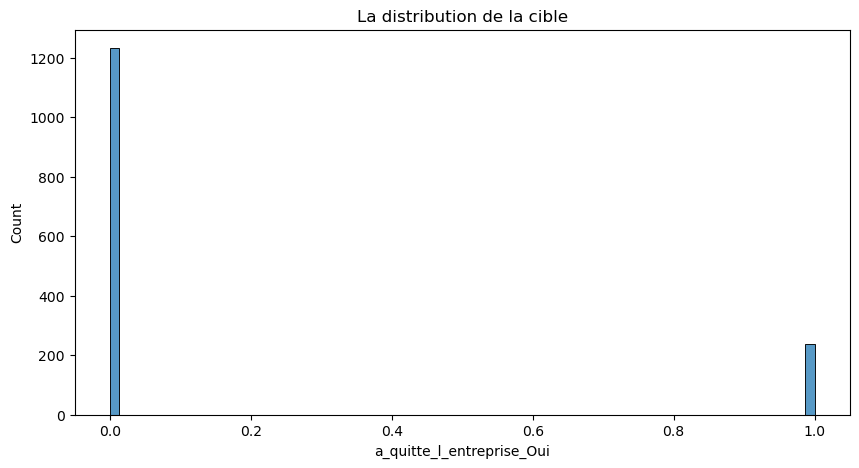

In [29]:
# on recupere la cible ici a_quitte_l_entreprise_Oui
plt.figure(figsize=(10,5))
sns.histplot(df_corr['a_quitte_l_entreprise_Oui'])
plt.title('La distribution de la cible')
plt.show()

In [30]:
#sns.pairplot(df_corr)

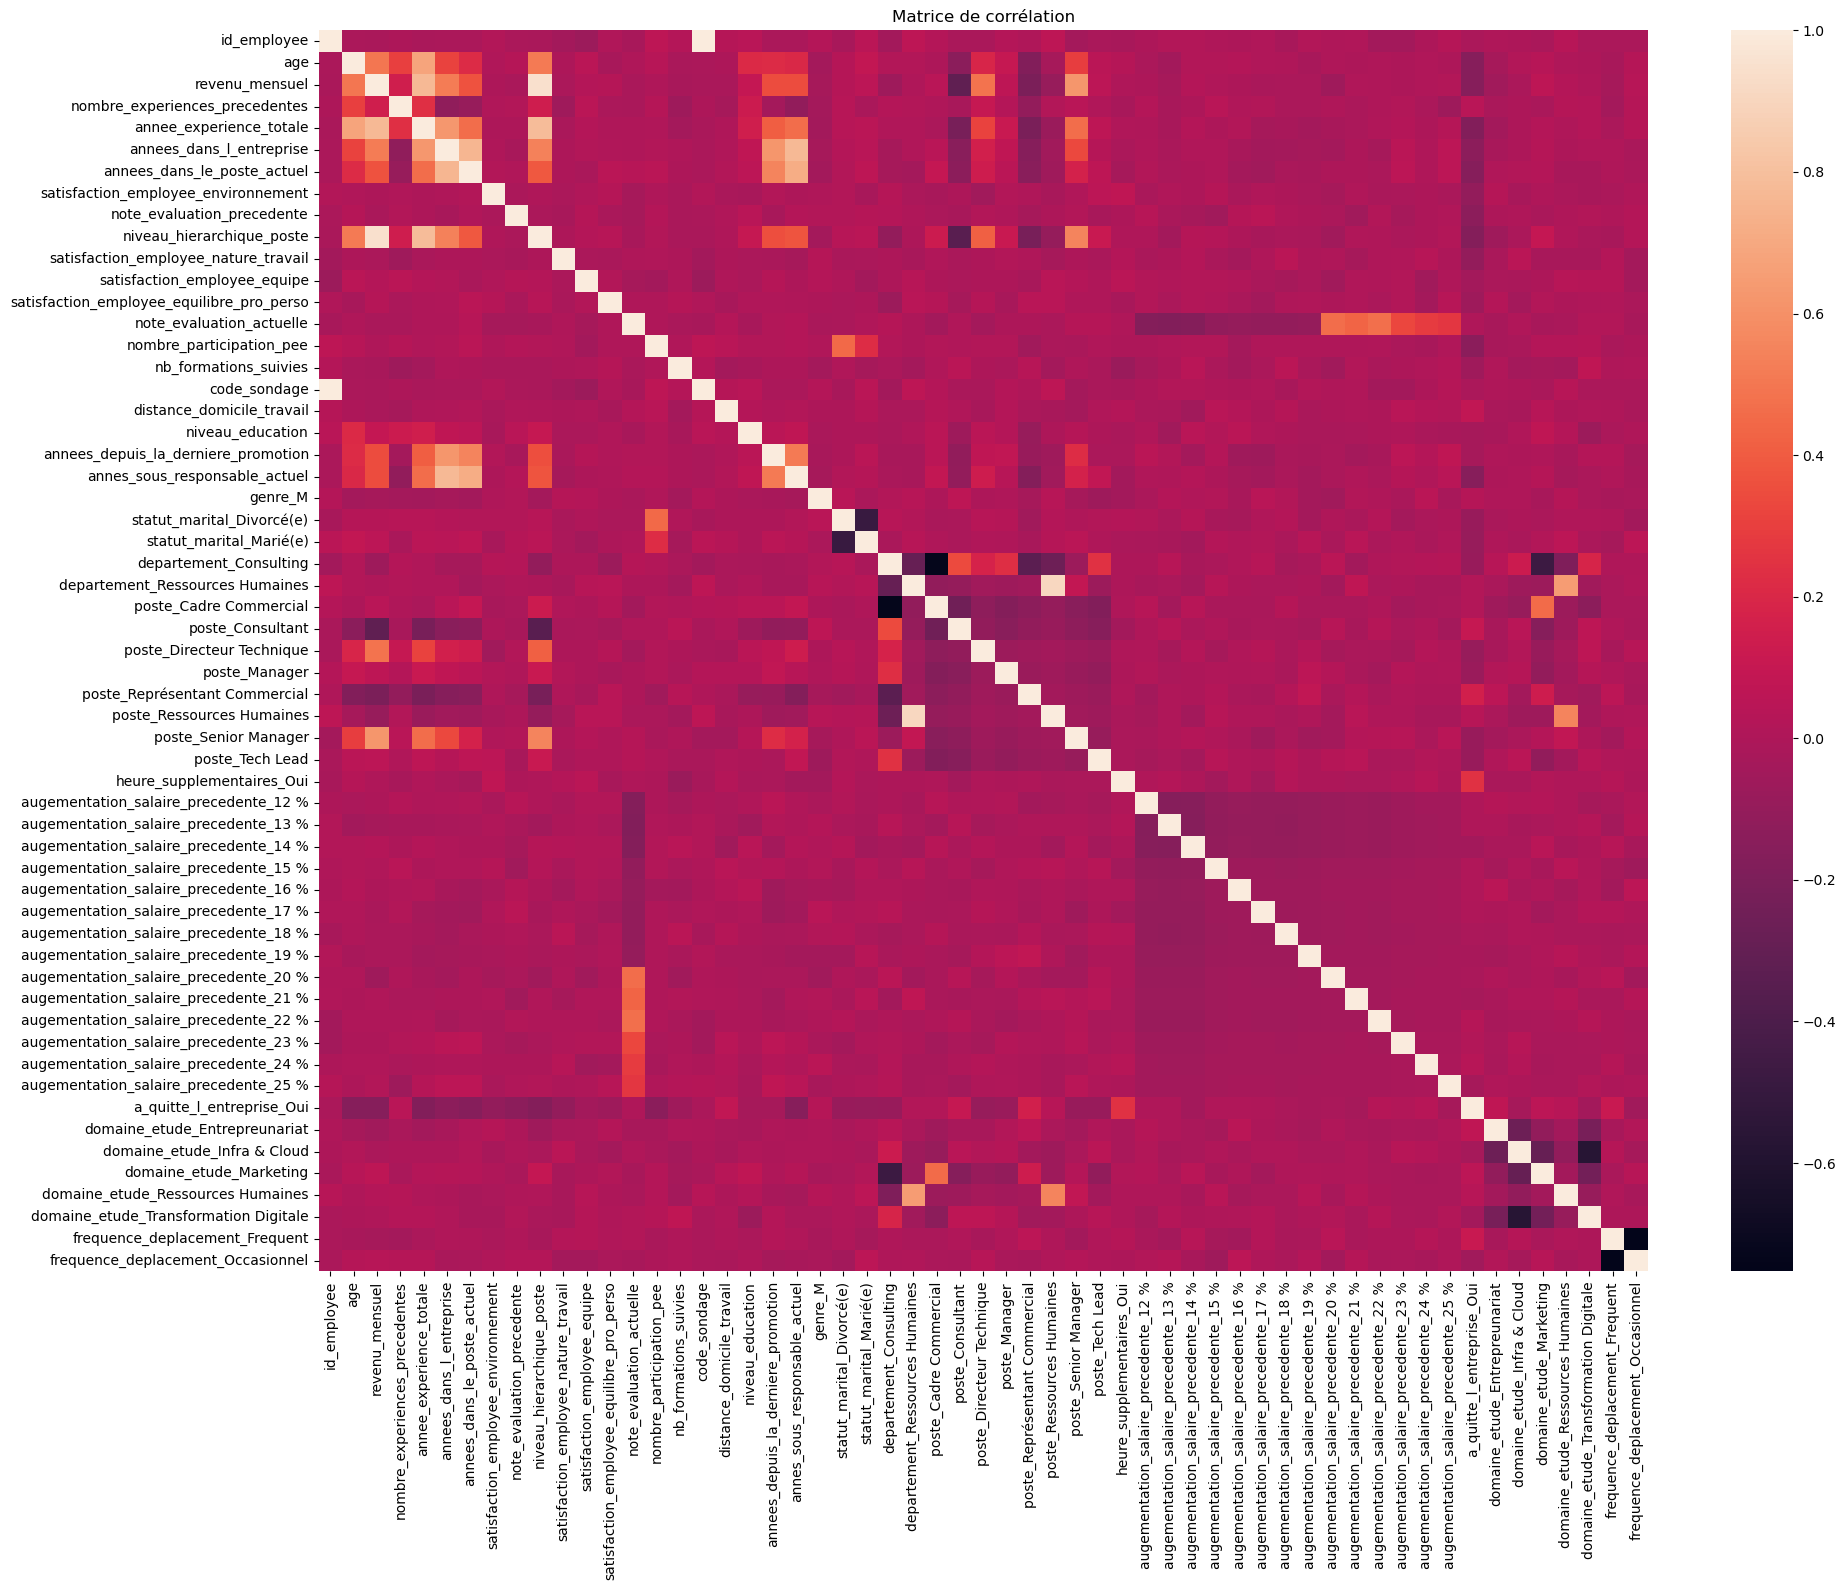

In [31]:
# on affiche graphiquement la corr()
plt.figure(figsize=(20,16))
sns.heatmap(df_corr.corr(numeric_only=True))
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

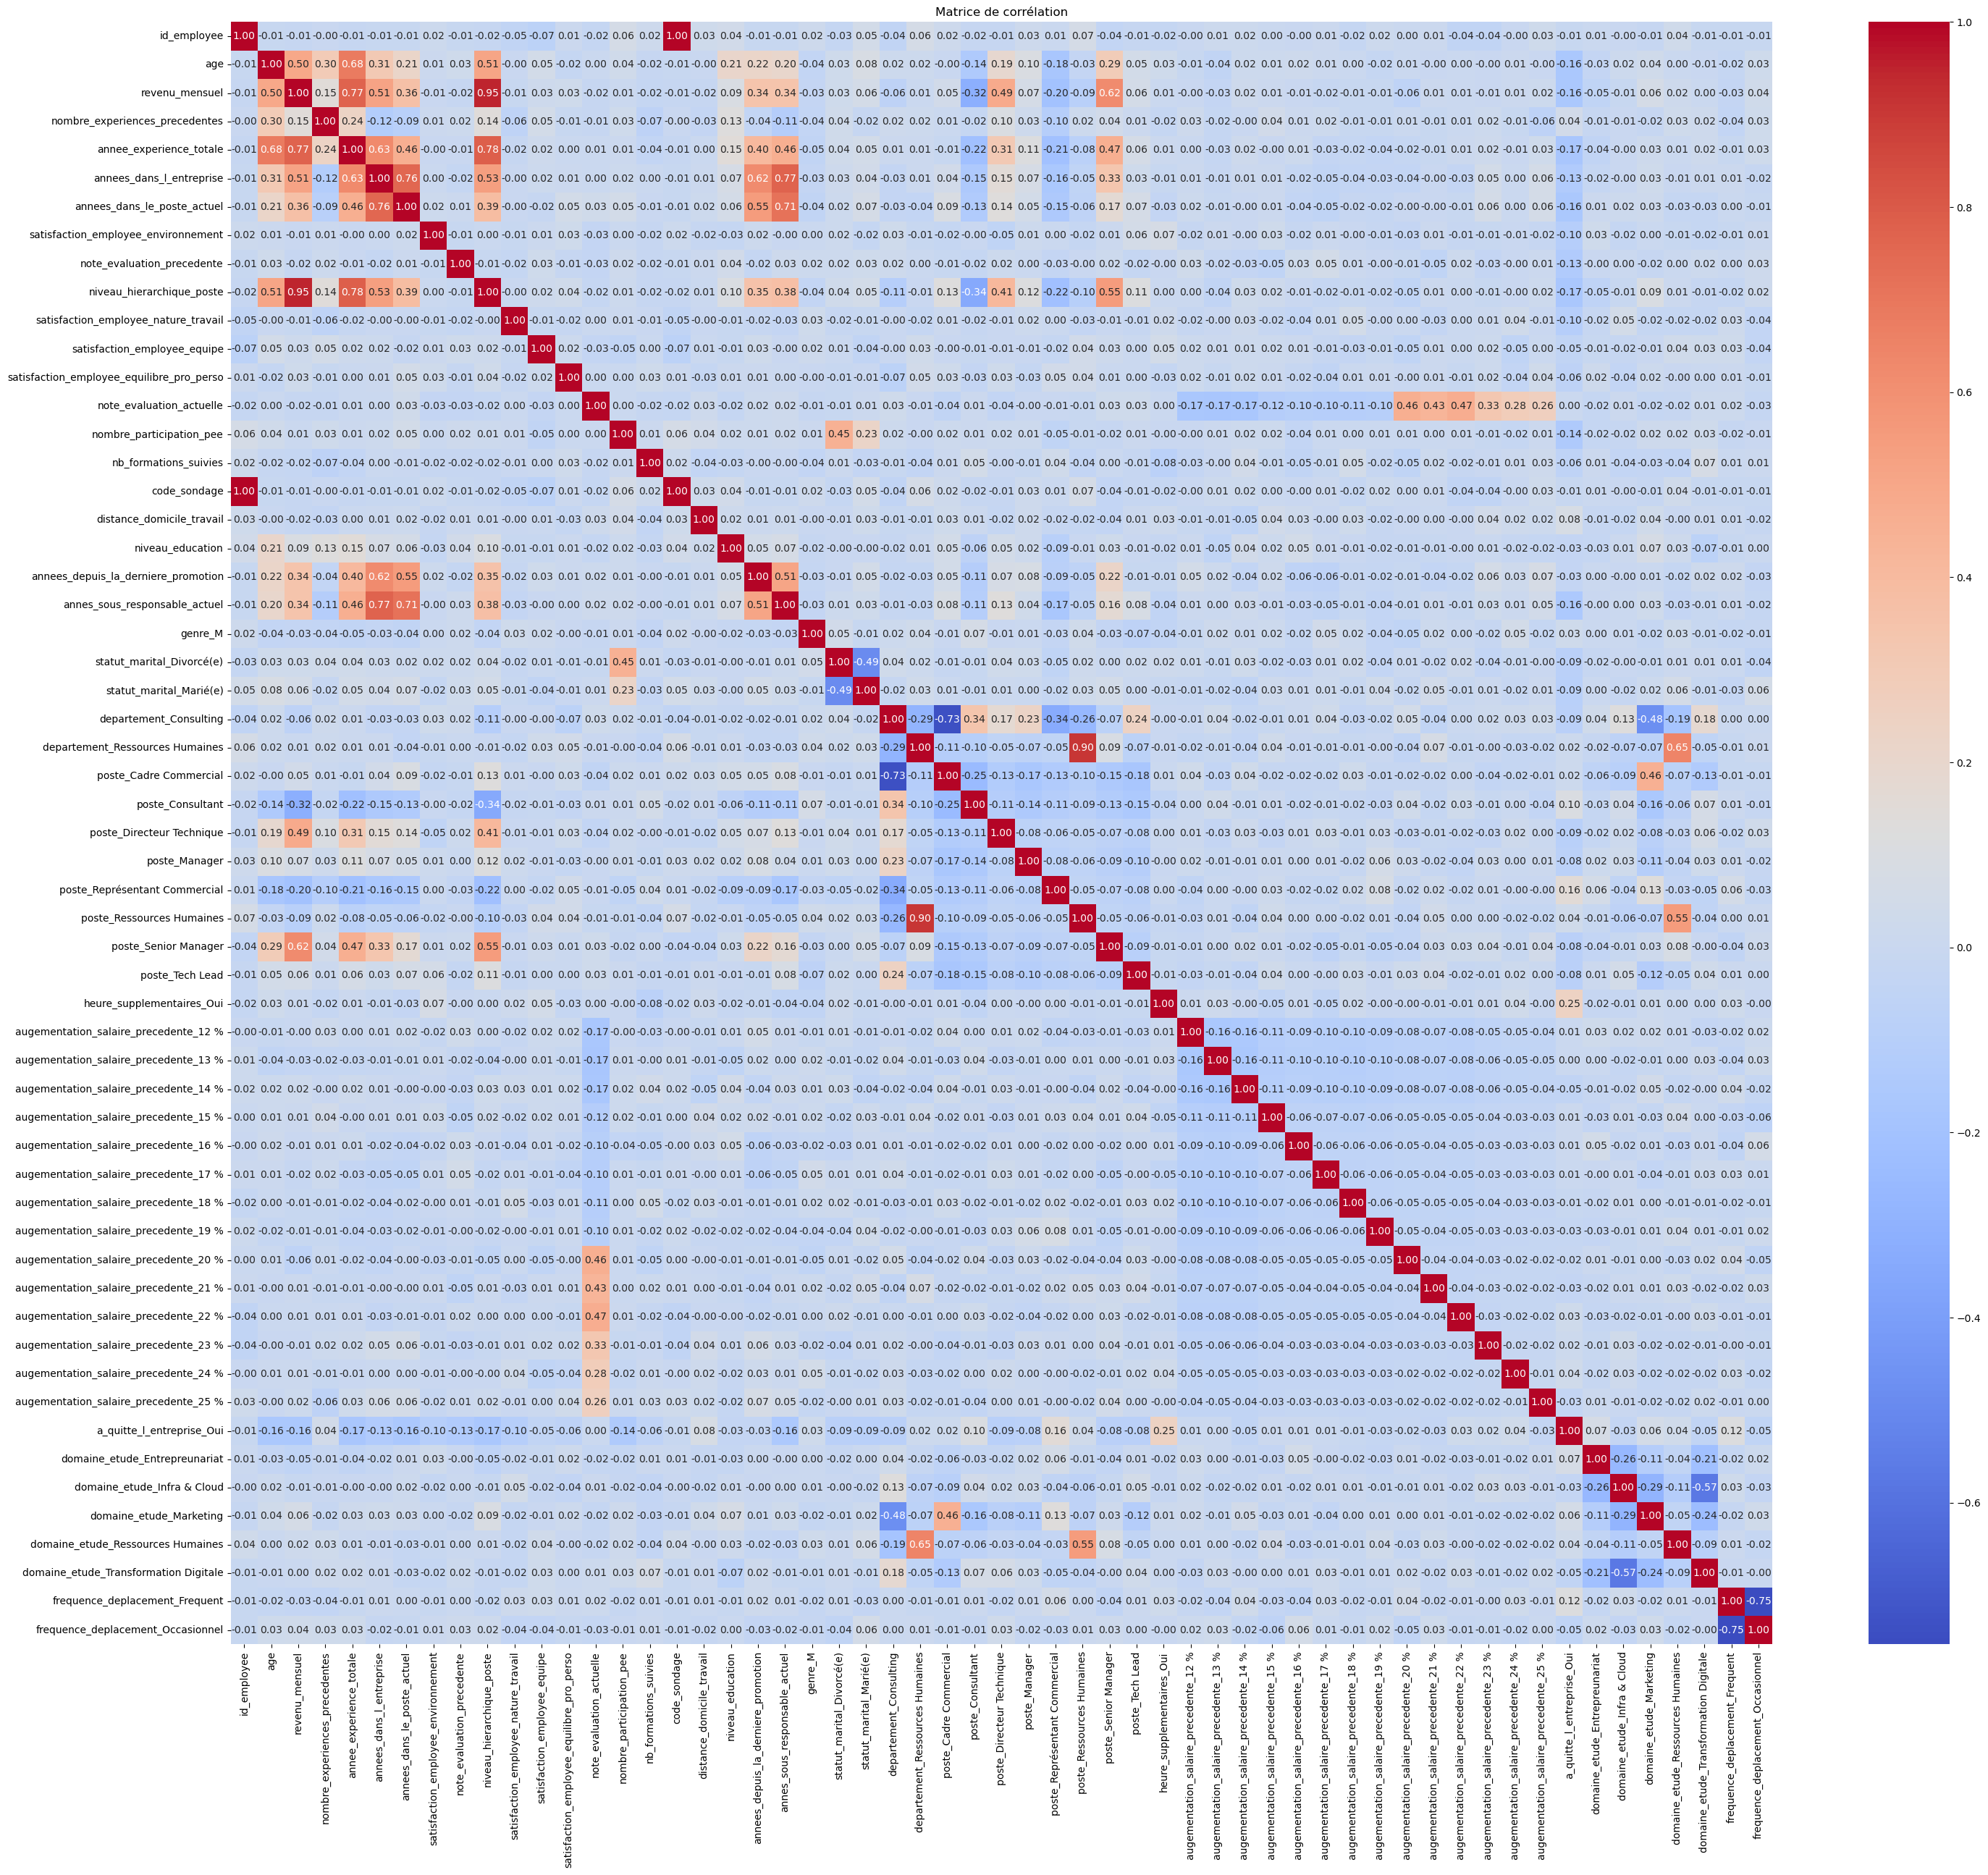

In [32]:
plt.figure(figsize=(30,26))
sns.heatmap(df_corr.corr(numeric_only=True),annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Modèles supervisés

In [35]:
# on décompose le X et y (features et la cible)
X = df_corr.copy()
# on supprime la target dans la features pour eviter le data Leakage
X = X.drop(columns=['a_quitte_l_entreprise_Oui'])
# on recupere le target
y = df_corr['a_quitte_l_entreprise_Oui']

In [36]:
# on separe ici les données dans le code complet X et y (train/test)
# j'utilise import train_test_split dans sklearn.model_selection (il vient du même module de GriDCV Search)
# liens doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [37]:
# X_train c'est 80% du dataset à utiliser
X_train.shape

(1176, 56)

In [38]:
# X_test c'est 20% du dataset à utiliser
X_test.shape

(294, 56)

### Scaling

In [39]:
# ici on vas realiser un scaling pour pour ramener toutes les features à la même échelle ex: 0 et 1
# on utilisera la méthode standardScaler() de sklearn.preprocessing import StandardScaler
# doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#scaler.fit(X_train) # on applique uniquement sur le train pour l'apprendre uniquement sur les features X_train
X_train_scaler = scaler.fit_transform(X_train) # on fit_transformes les données sur X_train 
X_test_scaler = scaler.transform(X_test) # on transformes les données sur X_test


In [40]:
# on verifie la moyenne
X_train_scaler.mean()

np.float64(-7.282804097395341e-18)

In [41]:
# on verifie la moyenne
X_train_scaler.std()

np.float64(1.0)

## Etape 3 - Réalisez un premier modèle de classification

In [42]:
# on vas utiliser le modele RandomForest avec les params par défaut
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor(max_depth=6 ,random_state=0)
regr.fit(X_train_scaler, y_train)
# on import tout
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# on commence par r2_score sur le data train

# TRAIN
y_pred_train = regr.predict(X_train_scaler)
print("R2 train:", r2_score(y_train, y_pred_train))

# TEST
y_pred_test = regr.predict(X_test_scaler)
print("R2 test:", r2_score(y_test, y_pred_test))

R2 train: 0.5991402836321504
R2 test: 0.08276401650396625


In [43]:
# on continue sur median_absolute_error(y_true, y_pred)MAE
print('MAE train : ',mean_absolute_error(y_train, y_pred_train)) # on calcul la racine carré du MSE
print('MAE test : ',mean_absolute_error(y_test, y_pred_test)) # on calcul la racine carré du MSE

MAE train :  0.1507577364248551
MAE test :  0.206576101554761


In [44]:
# permet de voir le max_depth idéeal pour tree
parameters = {'max_depth':np.arange(2, 30, 2)}
model = RandomForestRegressor(
    random_state = 808, max_depth=4
)
clf = GridSearchCV(model, parameters, cv = 5, scoring = 'neg_mean_squared_error', verbose = 1) # scoring on peut aussi utiliser r2 
clf.fit(X_train_scaler, y_train)
print('best params : ',clf.best_params_)
print('best score : ',clf.best_score_)
print('best estimator : ',clf.best_estimator_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
best params :  {'max_depth': np.int64(6)}
best score :  -0.11083607540249148
best estimator :  RandomForestRegressor(max_depth=np.int64(6), random_state=808)


NameError: name 'transactions' is not defined